# **#  Step 1: Importing Necessary Libraries**

---


We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.


For reading big csv files, one can use numpy as well as"pandas".

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [16]:
# Constants needed:
from astropy import constants as const
from astropy import units as u

H_0 = 69.8 * u.km / u.second / u.mpc   # Hubble constant in SI units
c = const.c   # Speed of light in m/s
G = const.G   # Gravitational constant in pc kg^-1 (m/s)^2
q0= -0.534     # Deceleration parameter (assumed from Planck fit)

Read the csv data into a python dataframe using the method below


In [17]:
df= pd.read_csv("/content/SDSS.csv", skiprows=1)  #Store Csv as a dataframe, df

print(df.columns.tolist()) #Prints all column headers

['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr', 'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr', 'obj_type']


# **#Step 2 : Calculating the Average Spectroscopic Redshift (`specz`) for Each Object**

---



When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [18]:
# Calculating the average specz for each objid:

averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first',}).reset_index()

averaged_df.describe()['specz']

,specz
count,92.000000
mean,0.080838
std,0.008578
min,0.069976
25%,0.077224
50%,0.080961
75%,0.082797
max,0.150886


To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group.

Find the mean, standard deviation and limits of the redshift from the data

In [19]:
mean = averaged_df['specz'].mean()
std = averaged_df['specz'].std()
lower_limit = mean - (3*std)
upper_limit = mean + (3*std)
print(f"Mean: {mean:.4}")
print(f"StD : {std:.3}")
print(f"Lower Limit: {lower_limit:.4}")
print(f"Upper Limit: {upper_limit:.4}")

Mean: 0.08084
StD : 0.00858
Lower Limit: 0.0551
Upper Limit: 0.1066


You can also use boxplot to visualize the overall values of redshift

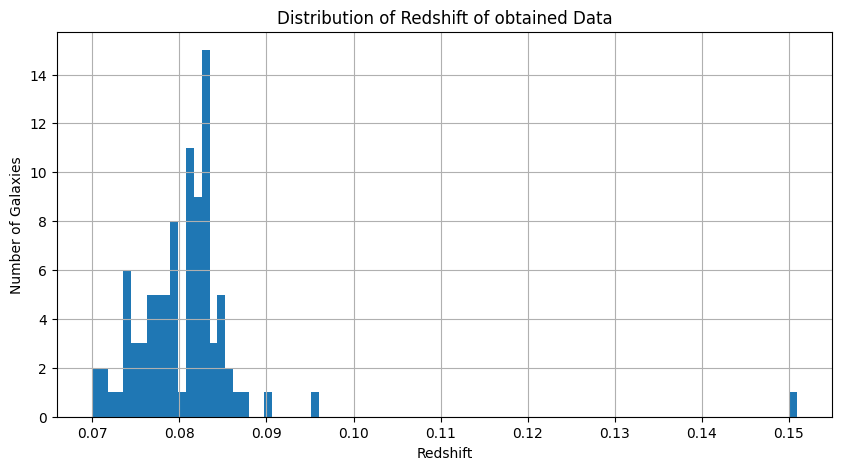

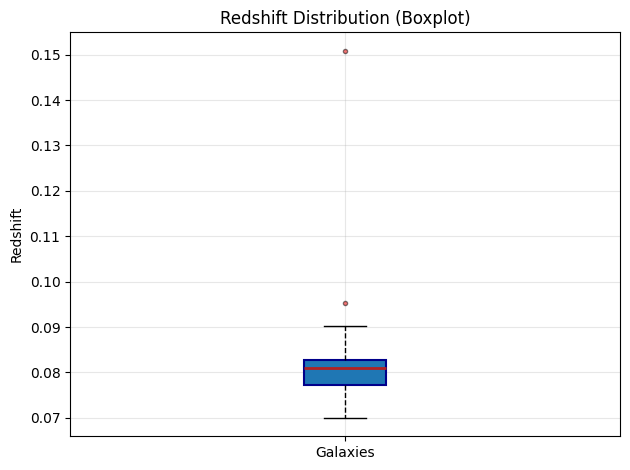

In [20]:
# Plot the distribution of redshift as histogram and a boxplot
plt.figure(figsize=(10, 5))

# First subplot - Histogram
import matplotlib.pyplot as plt
plt.subplot(1, 1, 1)
plt.title("Distribution of Redshift of obtained Data")
plt.hist(averaged_df['specz'],bins=90)
plt.xlabel("Redshift")
plt.ylabel("Number of Galaxies")
plt.grid()
plt.show()


# Second subplot - Boxplot
plt.subplot(1, 1, 1)
boxprops = dict(linestyle='-', linewidth=1.5, color='darkblue')
medianprops = dict(linestyle='-', linewidth=2, color='firebrick')
whiskerprops = dict(linestyle='--', linewidth=1, color='black')
capprops = dict(linestyle='-', linewidth=1, color='black')
flierprops = dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5)

plt.boxplot(averaged_df['specz'],
            vert=True,
            patch_artist=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops)
plt.title("Redshift Distribution (Boxplot)", fontsize=12)
plt.ylabel("Redshift", fontsize=10)
plt.grid(alpha=0.3)
plt.xticks([1], ['Galaxies'])  # Only show one label for the single boxplot

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

Filter the data based on the 3-sigma limit of redshift. We must remove all data points which are 3-sigma away from mean of redshift

In [29]:
# Filtering the data based on specz values, from the calculated upper and lower limits
redshifted_df = (averaged_df['specz']> lower_limit ) & (averaged_df['specz']< upper_limit)

filtered_df = averaged_df[redshifted_df].copy()

filtered_df.describe()

print(f"Filtered from {len(averaged_df)} to {len(filtered_df)} galaxies")

Filtered from 92 to 91 galaxies


Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift

In [22]:
# Calculating recessional velocity for corresp. redshift values
filtered_df.loc[:, 'rec_velocity'] = filtered_df['specz'] * (c/1000)
print(filtered_df[['specz', 'rec_velocity']].head())


      specz  rec_velocity
0  0.082457  24719.932747
1  0.081218  24348.666769
2  0.079564  23852.805546
3  0.080842  24235.764929
4  0.084575  25355.070050


Text(0, 0.5, 'Number of Galaxies')

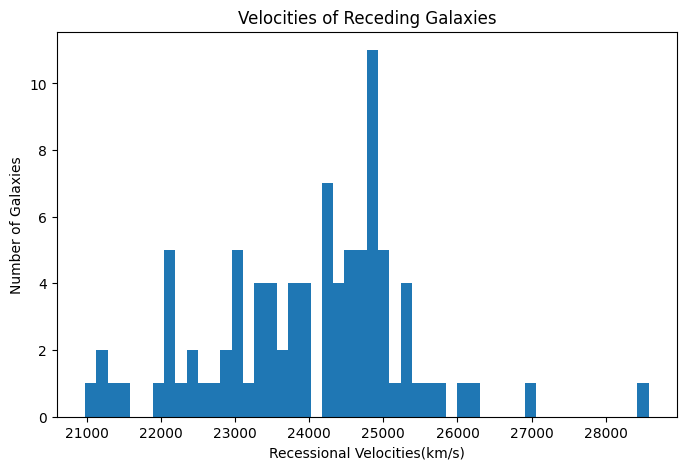

In [23]:
#Velocity vs Number of Galaxies histogram
plt.figure(figsize= (8,5))
plt.subplot(1, 1, 1)
plt.title("Velocities of Receding Galaxies")
plt.hist(filtered_df['rec_velocity'],bins=50)
plt.xlabel("Recessional Velocities(km/s)")
plt.ylabel("Number of Galaxies")

The above plot displays typical velocity distribution of different galaxies in our focussed galaxy cluster.

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

# **#Step 3 : Calculate Mean Redshift of Cluster**


---


We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [24]:
z_cr = filtered_df['specz'].mean()
z= filtered_df['specz']

# Applying Velocity Dispersion Formula
v_disp = (c/1000) * (((1 + z)**2 - (1 + z_cr)**2) / ((1 + z)**2 + (1 + z_cr)**2)) # C is in m/s, hence c/1000 denotes km/s
sigma_v = np.std(v_disp)

#Velocity dispersion is actually the standard deviation from the mean velocity of the group.


In [25]:

print(f"The value of the cluster redshift = {z_cr:.4f}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {sigma_v:.4f} km/s.")

The value of the cluster redshift = 0.0801
The characteristic value of velocity dispersion of the cluster along the line of sight = 1211.7794 km/s.


# **#Step 4 : Visualizing Angular Separation of Galaxies**

---


We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



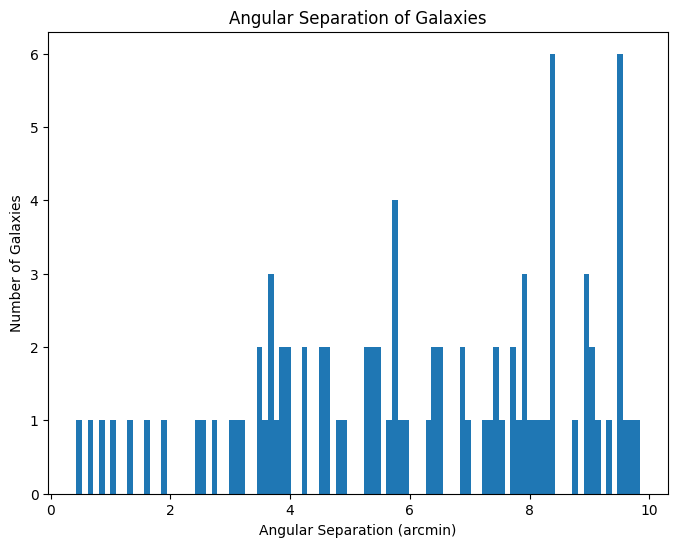

In [26]:
#Plot histogram for proj sep column

plt.figure(figsize=(8,6))
plt.subplot(1,1,1)
plt.title("Angular Separation of Galaxies")
plt.hist(filtered_df['proj_sep'],bins=100)
plt.xlabel('Angular Separation (arcmin)');
plt.ylabel('Number of Galaxies');

### Determining size and mass of the cluster:

### Step 5: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [30]:
# Calc of Cosmological Parameters

r= (c/1000) * z * ( 1- (z/2)*(1+q0)) / H_0  #Co-moving dist.
D_A= r/(1+z) #Angular Diam Dist. D_A

diameter_mpc= D_A * (filtered_df['proj_sep'].values * u.arcminute).to(u.rad)

d= diameter_mpc.mean()
print(f"Physical Diameter of the focused Galaxy cluster = {d * u.Mpc}")

Physical Diameter of the focused Galaxy cluster = 0.5523519331585163 Mpc


### Step 6: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [31]:
### Calculating the dynamical mass in solar masses:
M_dyn =3*((sigma_v*1000)**2)*(d *0.5*10**6*3*10**16)/(G*2*10**30)

print(f"Dynamical Mass of the cluster is {M_dyn:.2e} solar mass")

Dynamical Mass of the cluster is 2.73e+14 s2 kg / m3 solar mass
